In [4]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from timm import create_model
from tqdm import tqdm

# ── Config
SEED        = 42
DATA_DIR    = "dataset-soto-v2"
NUM_CLASSES = 6
IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 20
LR          = 3e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"Device: {DEVICE}")


Device: cuda


In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from PIL import Image

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3, 0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])



Menampilkan visualisasi untuk file: makassar-0597.jpg


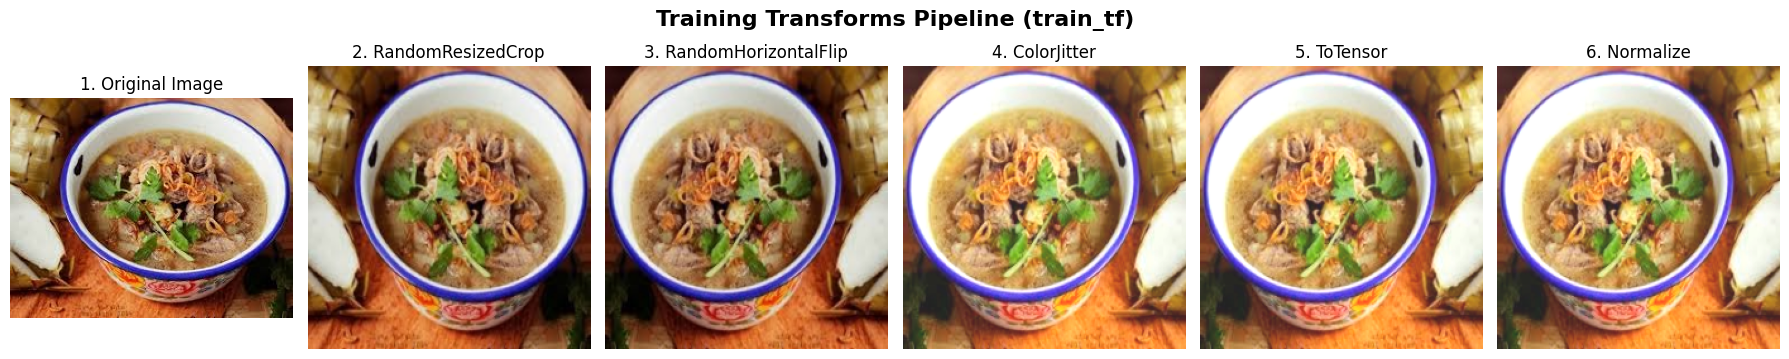

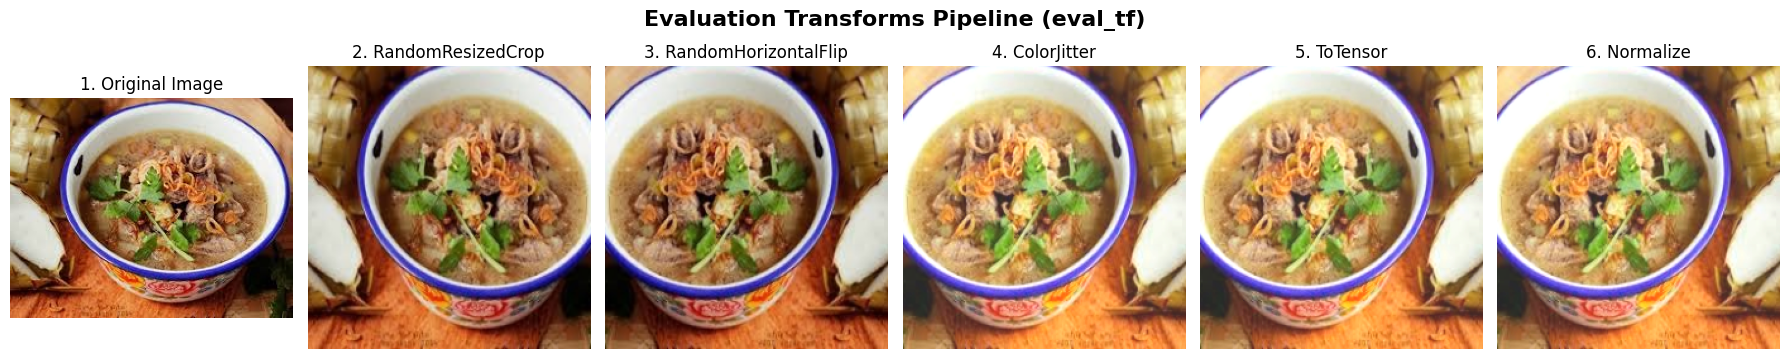

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from pathlib import Path

def visualize_transform_steps(img_path, transform_pipeline, title="Transform Steps"):
    """
    Fungsi untuk memvisualisasikan setiap langkah transformasi dalam transforms.Compose
    """
    # Load gambar asli
    img = Image.open(img_path).convert("RGB")
    transforms_list = transform_pipeline.transforms
    num_steps = len(transforms_list) + 1
    
    # Setup plot matplotlib
    fig, axes = plt.subplots(1, num_steps, figsize=(3 * num_steps, 4))
    
    # 1. Tampilkan gambar asli
    axes[0].imshow(img)
    axes[0].set_title("1. Original Image")
    axes[0].axis("off")
    
    current_data = img
    
    # Iterasi untuk setiap transformasi dalam pipeline
    for i, t in enumerate(transforms_list):
        # Aplikasikan transformasi pada data
        current_data = t(current_data)
        
        # Salin data untuk keperluan visualisasi agar tidak merusak tensor asli
        display_img = current_data
        
        # Jika hasil transformasi adalah Tensor PyTorch
        if isinstance(display_img, torch.Tensor):
            display_img = display_img.clone()
            
            # Jika transformasinya adalah Normalize, lakukan un-normalize 
            # agar gambar tidak terlihat gelap/distorsi saat di-plot
            if isinstance(t, transforms.Normalize):
                # Gunakan mean dan std dari ImageNet yang Anda definisikan sebelumnya
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                display_img = display_img * std + mean
            
            # Matplotlib butuh dimensi (Height, Width, Channel), sedangkan PyTorch (C, H, W)
            display_img = display_img.permute(1, 2, 0).numpy()
            display_img = np.clip(display_img, 0, 1) # Pastikan rentang nilai warna valid
            
        # Tampilkan hasil langkah ini
        transform_name = t.__class__.__name__
        axes[i+1].imshow(display_img)
        axes[i+1].set_title(f"{i+2}. {transform_name}")
        axes[i+1].axis("off")
        
    plt.suptitle(title, fontsize=16, fontweight="bold", y=0.95)
    plt.tight_layout()
    plt.show()

# ── Eksekusi Visualisasi

# Cari satu file gambar acak dari DATA_DIR (.jpg, .png, .jpeg)
sample_images = list(Path(DATA_DIR).rglob("*.jpg")) + list(Path(DATA_DIR).rglob("*.png")) + list(Path(DATA_DIR).rglob("*.jpeg"))

if len(sample_images) > 0:
    # Ambil gambar pertama yang ditemukan sebagai sampel
    sample_img_path = sample_images[0] 
    
    print(f"Menampilkan visualisasi untuk file: {sample_img_path.name}")
    
    # Tampilkan proses Train Transform
    visualize_transform_steps(sample_img_path, train_tf, title="Training Transforms Pipeline (train_tf)")
    
    # Tampilkan proses Eval Transform
    visualize_transform_steps(sample_img_path, eval_tf, title="Evaluation Transforms Pipeline (eval_tf)")
else:
    print(f"Error: Tidak menemukan file gambar di dalam direktori '{DATA_DIR}'. Pastikan path sudah benar.")